In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA availabe: {torch.cuda.is_available()}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print("Day 6 - PyTorch")

PyTorch version: 2.5.1+cu121
CUDA availabe: True
Device: GPU
Day 6 - PyTorch


In [2]:
# Tensor is PyTorchs's version of NumPy Array
# Key difference -tensor can live on gpu and track gradients

# Create tensors
t1 = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
t2 = torch.tensor([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])

print("=== Basic Tensor===")
print(f"t1: {t1}")
print(f"t1 shape: {t1.shape}")
print(f"t1 dtype: {t1.dtype}")
print(f"t1 device: {t1.device}")

print(f"\nt2:\n{t2}")
print(f"t2 shape: {t2.shape}")

# Move tensor to gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t1_gpu =t1.to(device) 
print(f"\nt1 on GPU: {t1_gpu.device}")

# From numpy - you'll do thid constantly
np_array = np.array([1.0, 2.0, 3.0])
from_numpy = torch.from_numpy(np_array)
print(f"\n From numPy: {from_numpy}")
print(f"dtype: {from_numpy.dtype}")

# Tensor operations -same as numpy
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(f"\n === Tensor Operations ===")
print(f"a+b = {a+b}")
print(f"a*b = {a*b}")
print(f"dot product = {torch.dot(a,b)}")
print(f"mean = {a.mean()}")
print(f"sum = {a.sum()}")


=== Basic Tensor===
t1: tensor([1., 2., 3., 4., 5.])
t1 shape: torch.Size([5])
t1 dtype: torch.float32
t1 device: cpu

t2:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
t2 shape: torch.Size([2, 3])

t1 on GPU: cuda:0

 From numPy: tensor([1., 2., 3.], dtype=torch.float64)
dtype: torch.float64

 === Tensor Operations ===
a+b = tensor([5., 7., 9.])
a*b = tensor([ 4., 10., 18.])
dot product = 32.0
mean = 2.0
sum = 6.0


In [8]:
# Autograd automatically computes gradients
# This is what makes backpropagation possible

print("=== Autograd ===\n")

# requires_grad = True tells PyTorch to track operations on this tensor
x = torch.tensor(3.0, requires_grad=True)
print(f"x= {x}")
print(f"required_grad: {x.requires_grad}")

# Define a simple function: y = x^2 +2x +1
y = x**2 + 2*x +1
print(f"\ny = x^2 + 2x + 1")
print(f"y = {y}")

# Compute gradient dy/dx
y.backward() #backpropagation

#dy/dx = 2x +2 =2(3) +2 =8
grad_value = x.grad.item()
print(f"Gradient dy/dx = {grad_value}")
print(f"Expected: 2(3) + 2 =8")

# More realistic example -loss function
print("\n=== Realistic Example ===")
# Imagine w is a weight in your neural network
w = torch.tensor(2.0, requires_grad=True)
b=torch.tensor(1.0, requires_grad=True)

# Simple prediciton: y_pred = w*x +b
x_input = torch.tensor(4.0)
y_true = torch.tensor(12.0)

y_pred =w * x_input +b
loss = (y_pred - y_true)**2 # MSE loss

print(f"w={w.item()}, b={b.item()}")
print(f"y_pred = {y_pred.item()}")
print(f"y_true = {y_true.item()}")
print(f"loss = {loss.item()}")

loss.backward()
print(f"\nGradient of loss w.r.t w :{w.grad.item():.4f}")
print(f"Gradient of loss w.r.t b: {b.grad.item():.4f}")
print("\n These gradients tell us which direction to adjudt w and b")
print("to reduce the loss - this is gradient descent")

=== Autograd ===

x= 3.0
required_grad: True

y = x^2 + 2x + 1
y = 16.0
Gradient dy/dx = 8.0
Expected: 2(3) + 2 =8

=== Realistic Example ===
w=2.0, b=1.0
y_pred = 9.0
y_true = 12.0
loss = 9.0

Gradient of loss w.r.t w :-24.0000
Gradient of loss w.r.t b: -6.0000

 These gradients tell us which direction to adjudt w and b
to reduce the loss - this is gradient descent


==== Gradient Descent - watching weights update ===

step   w          b          y_pred     loss      
----------------------------------------------
0      2.2400         1.0600 9.0000     9.0000    
4      2.6175         1.1544 11.4308    0.3240    
8      2.6891         1.1723 11.8920    0.0117    
12     2.7027         1.1757 11.9795    0.0004    
16     2.7053         1.1763 11.9961    0.0000    


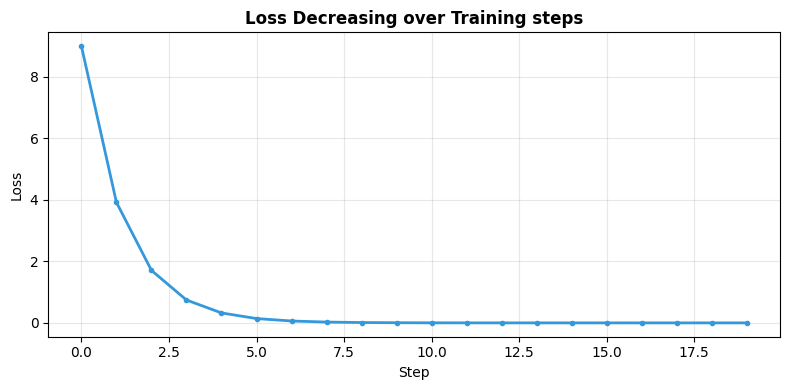

Final w: 2.7057
Final b: 1.1764
Final y_pred: 11.9993
Target y_true: 12.0


In [6]:
print("==== Gradient Descent - watching weights update ===\n")

# Reset weights
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

x_input = torch.tensor(4.0)
y_true = torch.tensor(12.0)

learning_rate =0.01
losses = []

print(f"{'step': <6} {'w':<10} {'b':<10} {'y_pred':<10} {'loss':<10}")
print("-"*46)

for step in range (20):
    #Forward pass
    y_pred = w*x_input +b
    loss = (y_pred - y_true)**2

    # Backward pass
    loss.backward()

    # Update weights manually - gradient descent
    with torch.no_grad():
        w -= learning_rate*w.grad
        b -= learning_rate*b.grad

    # Zero gradients - must do this every step
    w.grad.zero_()
    b.grad.zero_()

    losses.append(loss.item())

    if step % 4 == 0:
        print(f"{step:<6} {w.item():<10.4f} {b.item():10.4f} {y_pred.item():<10.4f} {loss.item():<10.4f}")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses, color="#3498db", linewidth=2, marker="o", markersize=3)
plt.title("Loss Decreasing over Training steps", fontweight="bold")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

print(f"Final w: {w.item():.4f}")
print(f"Final b: {b.item():.4f}")
print(f"Final y_pred: {(w*x_input +b).item():.4f}")
print(f"Target y_true: {y_true.item()}")

In [13]:
import torch.nn as nn

class SimpleEmbeddingNet(nn.Module):
    """
    A simple neural network thst learns to map
    text features to embedding-like vectors
    This is a simplified version of what sentence-transformers do.
    """

    def __init__(self, input_size:int, hidden_size:int, output_size:int):
        super().__init__()

        # Define layers
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),     #input -> hidden
            nn.ReLU(),                              # activation
            nn.Linear(hidden_size, hidden_size),    # hidden -> hidden
            nn.ReLU(),                              # activation
            nn.Linear(hidden_size, output_size)     # hidden -> output
        )

    def forward(self, x: torch.Tensor)-> torch.Tensor:
        return self.network(x)
    

# Create the network
model = SimpleEmbeddingNet(
    input_size=10,      # 10 input features
    hidden_size=32,     # 32 neurons in hidden layers
    output_size=8       # 8-dimensional embedding
)

print("=== Network Architecture ===")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

# Move to GPU
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"\nModel on: {device}")

# Test forward pass
sample_input = torch.randn(4, 10).to(device) # batch of 4 documents
output = model(sample_input)
print(f"\nInput shape: {sample_input.shape} (4 documents, 10 features each)")
print(f"\nOutput shape: {output.shape} (4 documents, 8-dim embeddings)")
print(f"\nSample embedding:\n{output[0].detach().cpu().numpy().round(4)}")

=== Network Architecture ===
SimpleEmbeddingNet(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=8, bias=True)
  )
)

Total parameters: 1672
Trainable parameters: 1672

Model on: cuda

Input shape: torch.Size([4, 10]) (4 documents, 10 features each)

Output shape: torch.Size([4, 8]) (4 documents, 8-dim embeddings)

Sample embedding:
[-0.0583  0.0525 -0.0682  0.1489 -0.2173 -0.1427 -0.0846 -0.1765]


=== Training SimpleEmbeddingNet ===

Epoch   0/50 | Loss: 0.324477
Epoch  10/50 | Loss: 0.295349
Epoch  20/50 | Loss: 0.277948
Epoch  30/50 | Loss: 0.261203
Epoch  40/50 | Loss: 0.245591

Final loss: 0.232298
Improvement: 28.4%


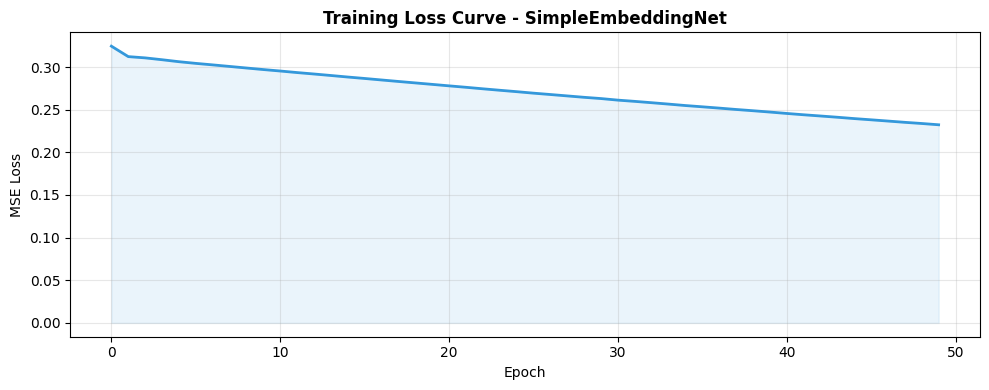

In [18]:
# Training loop - the complete pattern you'll use forever
print("=== Training SimpleEmbeddingNet ===\n")

# Hyperparameters
EPOCHS = 50
LEARNING_RATE = 0.001
BATCH_SIZE = 16

# Generate fake training data
# In real life this comes from your document chunks
torch.manual_seed(42)
X_train = torch.randn(100, 10).to(device) # 100 docs, 10 features
Y_train = torch.randn(100, 8).to(device)  # 100 target embeddings

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

#Training loop
losses = []

for epoch in range(EPOCHS):
    model.train()   # set model to training mode

    epoch_loss =0
    num_batches = 0

    # Mini-batch training
    for i in range(0, len(X_train), BATCH_SIZE):
        # Get Batch
        X_batch = X_train[i:i+BATCH_SIZE]
        Y_batch = Y_train[i:i+BATCH_SIZE]

        # Forward pass
        y_pred = model(X_batch)
        loss = criterion(y_pred, Y_batch)

        # Backward pass
        optimizer.zero_grad()   # clear gradients
        loss.backward()         # compute gradients
        optimizer.step()        # update weights

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)

    if epoch%10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")
print(f"Improvement: {((losses[0]-losses[-1])/losses[0]*100):.1f}%")

# Plot training curve
plt.figure(figsize=(10,4))
plt.plot(losses, color="#3498db", linewidth=2)
plt.fill_between(range(len(losses)), losses, alpha=0.1, color="#3498db")
plt.title("Training Loss Curve - SimpleEmbeddingNet", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()




In [20]:

import os

# Save model
save_path = "simple_embedding_net.pth"
torch.save({
    "epoch":EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "final_loss": losses[-1],
    "architecture":{
        "input_size": 10,
        "hidden_size": 32,
        "output_size":8
    }
}, save_path)

print(f"Model saved to {save_path}")
print(f"File size: {os.path.getsize(save_path) / 1024:.1f} KB")

# Load model
checkpoint = torch.load(save_path, map_location=device, weights_only=False)

# Recreate model with same architecture
loaded_model = SimpleEmbeddingNet(
    input_size=checkpoint["architecture"]["input_size"],
    hidden_size=checkpoint["architecture"]["hidden_size"],
    output_size=checkpoint["architecture"]["output_size"]
).to(device)

loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval() # set to evaluation mode

print(f"\nModel loaded successfully")
print(f"Trained for: {checkpoint['epoch']} epochs")
print(f"Final loss: {checkpoint['final_loss']:.6f}")

# Verify loaded model gives same output
test_input = torch.randn(1, 10).to(device)

model.eval()
with torch.no_grad():
    original_output = model(test_input)
    loaded_output = loaded_model(test_input)

print(f"\nOutputs match: {torch.allclose(original_output, loaded_output)}")
print(f"Sample output: {original_output[0].cpu().numpy().round(4)}")

Model saved to simple_embedding_net.pth
File size: 27.4 KB

Model loaded successfully
Trained for: 50 epochs
Final loss: 0.232298

Outputs match: True
Sample output: [ 0.0324  1.1452 -1.0672  0.2859  0.4415 -0.4355 -0.9675 -0.4893]
